In [1]:
import numpy as np
import matplotlib.pyplot as plt
from load_dataset import loadDataSet
from mean_covariance import compute_mu_C, compute_C, vcol, vrow
from normalize import normalizeDataSet

filename = "dataset/trainData.txt"

numFeatures = 6

## Data Loading and normalization

In [2]:
features, labels = loadDataSet(filename, numFeatures)

print(f"features shape: {features.shape}\nLabels shape: {labels.shape}")

features shape: (6, 6000)
Labels shape: (6000,)


In [3]:
#Mean and Covariance
mu, C = compute_mu_C(features)
print(f"mu shape: {mu.shape}\nC shape: {C.shape}")
print(f"mu: {mu}\nC: {C}")

mu shape: (6, 1)
C shape: (6, 6)
mu: [[ 0.00170711]
 [ 0.00503903]
 [-0.00560753]
 [ 0.00109537]
 [-0.00700025]
 [ 0.00910515]]
C: [[ 1.00134304e+00  5.16755817e-03  1.76746375e-03  1.45268757e-02
   1.00066790e-02 -1.29591239e-02]
 [ 5.16755817e-03  9.98352699e-01 -1.58354137e-02 -4.40650280e-04
  -4.01307317e-03 -8.17687100e-04]
 [ 1.76746375e-03 -1.58354137e-02  1.00248180e+00 -4.37060381e-01
  -2.68600594e-02  6.34388503e-03]
 [ 1.45268757e-02 -4.40650280e-04 -4.37060381e-01  9.90293894e-01
   2.53357434e-02  8.26930215e-03]
 [ 1.00066790e-02 -4.01307317e-03 -2.68600594e-02  2.53357434e-02
   1.00119747e+00  8.75793087e-04]
 [-1.29591239e-02 -8.17687100e-04  6.34388503e-03  8.26930215e-03
   8.75793087e-04  9.97223742e-01]]


In [4]:
#Normalize the dataset
normalizedFeatures = normalizeDataSet(features, mu)
print(f"Normalized features shape: {normalizedFeatures.shape}")
#show all the 6 features for sample 0, before and after normalzation
print(f"features, sample0 before norm: {features[:, 0]}\nfeature, sample0 after norm: {normalizedFeatures[:, 0]}") 


Normalized features shape: (6, 6000)
features, sample0 before norm: [ 1.85284048 -0.16436898  1.09839078 -0.93073689 -1.0193342   1.16696309]
feature, sample0 after norm: [ 1.84989155 -0.16954771  1.1026309  -0.93638768 -1.01172838  1.15946855]


### Uni-variate Gaussian Models

In this section I will try to fit uni-variate Gaussian models to the different features of the different classes of the project
dataset. 
- For each class, for each component of the feature vector of that class, I compute the ML estimate
for the parameters of a 1D Gaussian distribution

In [5]:
import sys
ggm_path = './models/ggm'
if not ggm_path in sys.path:
    sys.path.append(ggm_path)

import logpdf_loglikelihood_GAU as logpdf_functions

In [6]:
print(f"Dataset shape: {normalizedFeatures.shape}")
print(f"M is {normalizedFeatures.shape[0]}")
print(f"N is {normalizedFeatures.shape[1]}")

Dataset shape: (6, 6000)
M is 6
N is 6000


Since the dataset has $M = 6$ dimensions, I will calculate the *log-pdf* of the **MVG** distibution, wich in the log-domain is written as:
$$
\log \mathcal{N}(x \mid \mu, \Sigma) =
- \frac{M}{2} \log 2\pi
- \frac{1}{2} \log |\Sigma|
- \frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)
$$ 
where $\Sigma$ is the Covariance Matrix, $\mu$ is the mean. <br>
The ML estimate for the parameters of a Multivariate Gaussian distribution correspond to the empirical
dataset mean and the empirical dataset covariance, which are:
$$
\mu_{ML} = \frac{1}{N} \sum_{i=1}^{N} x_i , \quad 
\Sigma_{ML} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)(x_i - \mu)^T
$$

logpdf shape: (6000,)


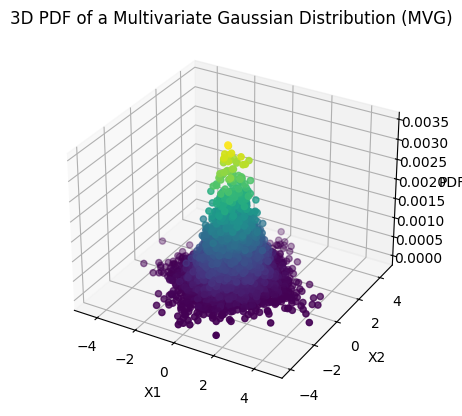

In [7]:
logpdf = logpdf_functions.logpdf_GAU_ND(normalizedFeatures, mu, C)
print(f"logpdf shape: {logpdf.shape}")

logpdf_functions.plotPdf3D(normalizedFeatures, logpdf)

In [8]:
normalizedFeatures.shape

(6, 6000)

In [9]:
normalizedFeatures[0:1, labels == 0].shape

(1, 2990)

In [10]:
#Compute log pdf for feature 0, class 0
feature0_class0 = normalizedFeatures[0, labels == 0]
C

array([[ 1.00134304e+00,  5.16755817e-03,  1.76746375e-03,
         1.45268757e-02,  1.00066790e-02, -1.29591239e-02],
       [ 5.16755817e-03,  9.98352699e-01, -1.58354137e-02,
        -4.40650280e-04, -4.01307317e-03, -8.17687100e-04],
       [ 1.76746375e-03, -1.58354137e-02,  1.00248180e+00,
        -4.37060381e-01, -2.68600594e-02,  6.34388503e-03],
       [ 1.45268757e-02, -4.40650280e-04, -4.37060381e-01,
         9.90293894e-01,  2.53357434e-02,  8.26930215e-03],
       [ 1.00066790e-02, -4.01307317e-03, -2.68600594e-02,
         2.53357434e-02,  1.00119747e+00,  8.75793087e-04],
       [-1.29591239e-02, -8.17687100e-04,  6.34388503e-03,
         8.26930215e-03,  8.75793087e-04,  9.97223742e-01]])

In [11]:
feature0_class0.shape

(2990,)

In [12]:
np.cov(feature0_class0, rowvar=False)

array(0.56900742)

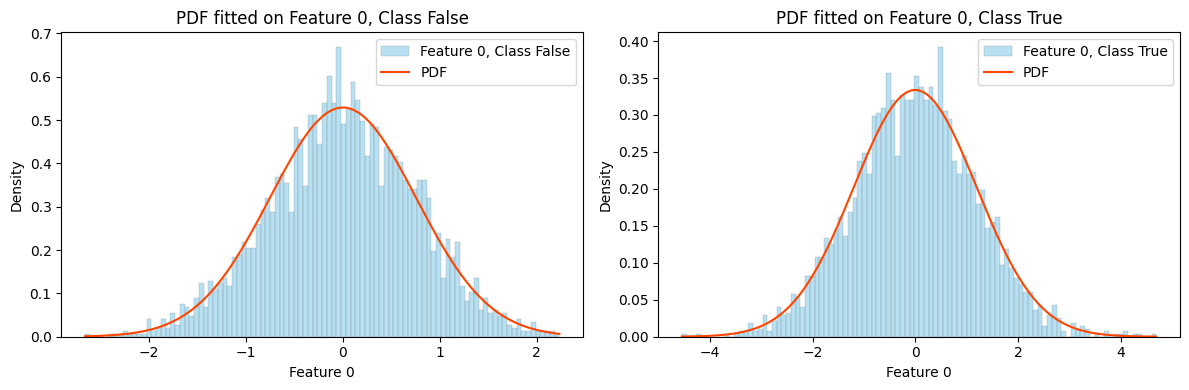

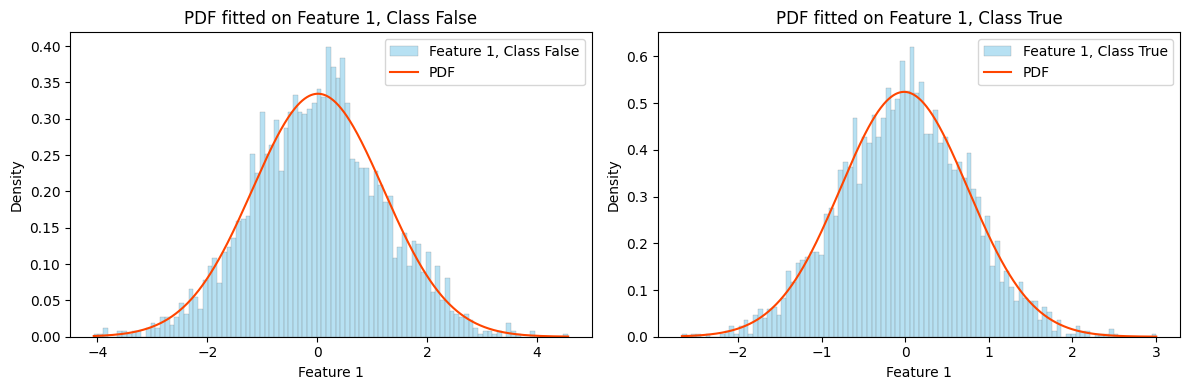

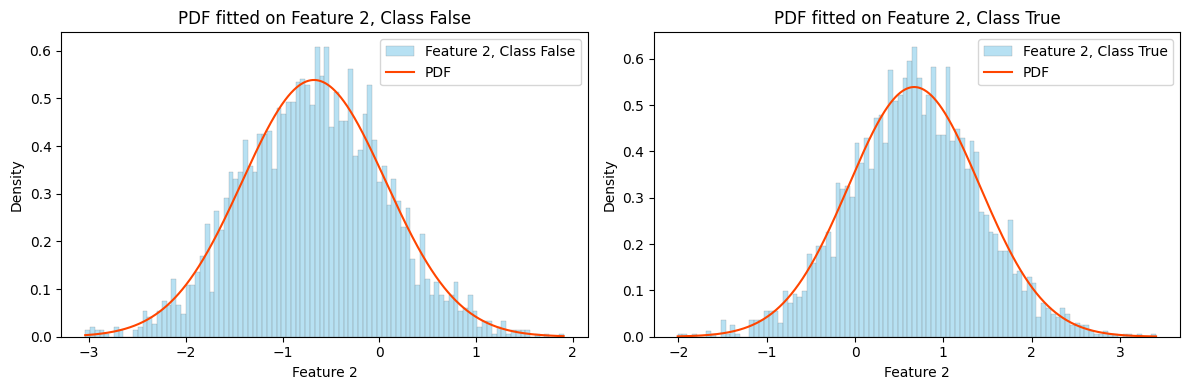

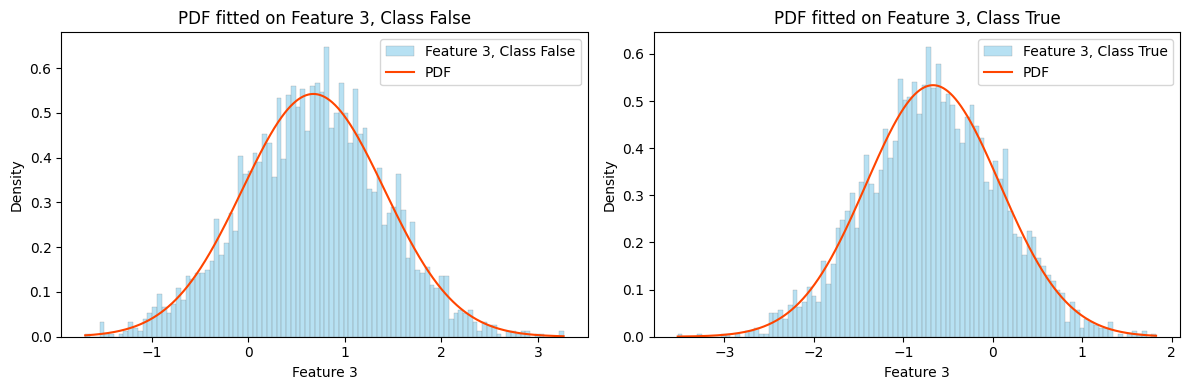

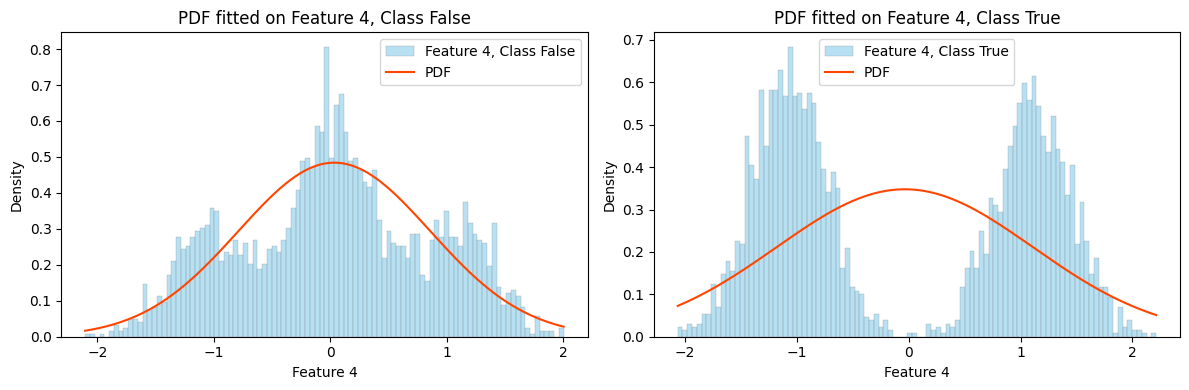

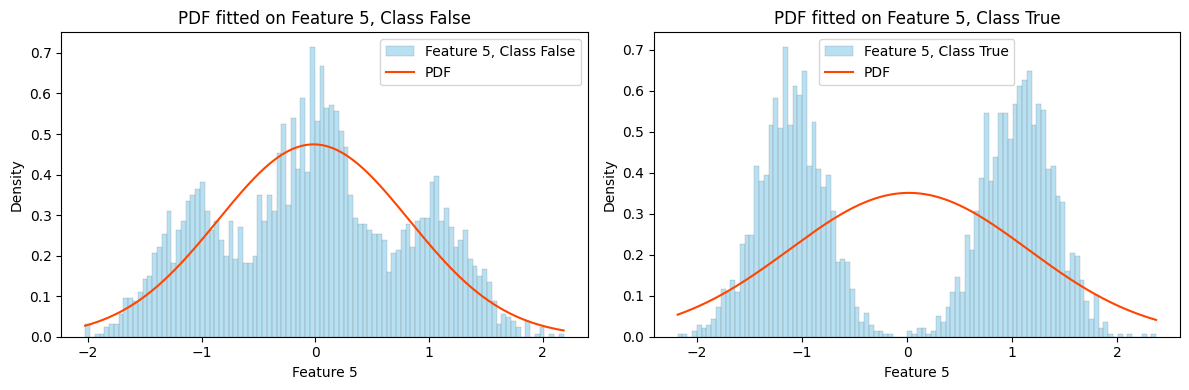

In [13]:
#For each feature, for each class, compute the log pdf
logpdf_feature_class = np.zeros((numFeatures, 2))

classLabels = {0: 'False', 1: 'True'}

for i in range(numFeatures):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))     #create a figure with 2 subplots: one for class 0 and one for class 1

    for cls in classLabels.keys():

        D_i = normalizedFeatures[i:i+1, labels == cls]       #select feature i, class cls -> shape is (1, P) where P is the number of samples in class cls
        mu_i = D_i.mean()                                   #compute mean for feature i, class 0
        C_i = compute_C(D_i, mu_i)                          #compute covariance for feature i, class 0
        
        
        #Compute log pdf for feature i, class 0
        log_pdf_i_0 = logpdf_functions.logpdf_GAU_ND(D_i, mu_i, C_i)  #compute log pdf for feature i, class 0 

        axes[cls].hist(D_i.ravel(), bins=100, density=True, label=f'Feature {i}, Class {classLabels[cls]}', color='skyblue', alpha=0.6, edgecolor='grey', linewidth = 0.3)  #plot histogram for feature i, class cls
        XPlot = np.linspace(D_i.min(), D_i.max(), 1000)
        axes[cls].plot(XPlot.ravel(), np.exp(logpdf_functions.logpdf_GAU_ND(vrow(XPlot), mu_i, C_i)), label='PDF', color='orangered')  #plot pdf for feature i, class cls
            
        axes[cls].set_title(f'PDF fitted on Feature {i}, Class {classLabels[cls]}')
        axes[cls].legend()
        axes[cls].set_xlabel(f'Feature {i}')
        axes[cls].set_ylabel('Density')
        logpdf_feature_class[i, cls] = log_pdf_i_0.mean()

    plt.tight_layout()
    plt.show()


   






As we can see from the charts, the Gaussian density can be fitted well on features $0, 1, 2, 3$ whereas if applied on features $4, 5$ it produces far worse results

## Generative Gaussian Models (gmm) application on the dataset
Now I'll try to fit some Generative Gaussian Models on the dataset, in order to test their goodness. <br>
First of all, let's split the dataset into a training part (*DTR, LTR*) and a validation/estimation part (*DVAL, LVAL*). In order to make the models comparable, I shall use the **same split** used when fitting PCA and LDA models:

In [14]:
preSplit = np.load("./split/split_data.npz")

DTR = preSplit["DTR"]
LTR = preSplit["LTR"]
DVAL = preSplit["DVAL"]
LVAL = preSplit["LVAL"]

print(f"DTR shape: {DTR.shape}\nLTR shape: {LTR.shape}\nDVAL shape: {DVAL.shape}\nLVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
LTR shape: (4000,)
DVAL shape: (6, 2000)
LVAL shape: (2000,)


### 1. MVG (Multivariate Gaussian) Classifier
First, let's import the model functions:

In [15]:
MVG_path = './models/ggm/MVG'
if not MVG_path in sys.path:
    sys.path.append(MVG_path)

import MVG

The optimal Bayes decision is to select for each test point the class with highest **posterior probability**: having class $c$ and $x_{t}$ as test point, we can thus write:
$$
c_{t}^{*} = argmax_{c} P (C_{t} = c \mid \mathbf{X}_t = \mathbf{x}_t) \rightarrow We \space assign \space x_{t} \space to \space the \space class \space having \space the \space highest \space Posterior \space probability
$$ 
We will assume that the samples are independent and identically distributed (*i.i.d.*) according to $(\mathbf{X}_t, C_{t}) ∼ (\mathbf{X}, C)$. <br>
Let $f_{X,C}$ be the joint density of $X, C$: we can
compute the joint likelihood for the hypothesized class $c$ for the observed test
sample $x_{t}$ as $f_{X,C}(x_{t}, c)$ and then use **Bayes rule** to compute the class posterior
probability:
$$
P(C_t = c \mid \mathbf{X}_t = \mathbf{x}_t) = \frac{f_{\mathbf{X},C}(\mathbf{x}_t, c)}{\sum_{c' \in C} f_{\mathbf{X},C}(\mathbf{x}_t, c')}
$$
We can factorize the joint density as:
$$
f_{\mathbf{X}_t, C_t}(\mathbf{x}_t, c) = f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c) P(c)
$$
Where:
- $f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c)$ is the class conditional distribution 
- $P(c)$ is called *Prior probabilty*: it's application-dependent and describes the probability of the class being $c$ **before** we observe $x_{t}$ 

In this specific case, we assume that our data, given the class, can be described by a **Gaussian distribution**:
$$
(\mathbf{X}_t \mid C_{t} = c) ∼ (\mathbf{X} \mid C = c) ∼ \mathcal{N}(\mathbf{µ_{c}}, \mathbf{Σ_{c}})
$$
If we knew $\mathbf{µ_{c}}$, $\mathbf{Σ_{c}}$ then we could compute the conditional this way;
$$
f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c) = \mathcal{N}(\mathbf{µ_{c}}, \mathbf{Σ_{c}})
$$
The problem is that we don't have **these parameters** $\theta = [(\mathbf{µ_{1}}, \mathbf{Σ_{1}}), . . . ,(\mathbf{µ_{k}}, \mathbf{Σ_{k}})] $, where $k$ is the number of different classes. <br>
However, since we have at our disposal a *labeled Dataset*, we can assume:
- Gaussian distribution for $\mathbf{X} \mid C$
- That, given the model parameters $\theta$, all the samples observations are *i.i.d* 

After (and only after) making these assumptions, we can plug in the **Maximum Likelihood Estimators** (*MLE*), which, for a **MVG** distribution, are the empirical mean and covariance matrix of each class. So, for each class $c$ we can compute the two estimators:
$$
\mu^{MLE}_{c} = \frac{1}{N_c} \sum_{i} x_{c,i}, \quad 
\Sigma^{MLE}_{c} = \frac{1}{N_c} \sum_{i} (x_{c,i} - \mu^*_c)(x_{c,i} - \mu^*_c)^T
$$
Where $x_{c,i}$ is the $i$-th sample of class $c$. <br>
The ML estimators are computed this way:

In [16]:
#Compute the ML estimators of a MVG distribtion, which are the empirical mean and covariance of the training data
ML_params = MVG.computeParams_ML(DTR, LTR)
mu_0 = ML_params[0][0] #mean for class 0 (false)
C_0 = ML_params[0][1]  #covariance for class 0 (false)
mu_1 = ML_params[1][0] #mean for class 1 (true)
C_1 = ML_params[1][1]  #covariance for class 1 (true)

print(f"mu_0 shape: {mu_0.shape}\nC_0 shape: {C_0.shape}\nmu_1 shape: {mu_1.shape}\nC_1 shape: {C_1.shape}")
print(f"mu_0: {mu_0}\nC_0: {C_0}\nmu_1: {mu_1}\nC_1: {C_1}")

mu_0 shape: (6, 1)
C_0 shape: (6, 6)
mu_1 shape: (6, 1)
C_1 shape: (6, 6)
mu_0: [[-0.00822607]
 [ 0.01103328]
 [-0.66765899]
 [ 0.68274212]
 [ 0.02264805]
 [-0.02242518]]
C_0: [[ 6.00150483e-01  5.15945586e-05  1.90225386e-02  1.93341302e-02
   1.27876967e-02 -1.34818497e-02]
 [ 5.15945586e-05  1.44961338e+00 -1.61273162e-02 -1.59468029e-02
  -2.64588919e-02  2.29647800e-02]
 [ 1.90225386e-02 -1.61273162e-02  5.63949294e-01 -1.85016190e-03
  -6.90176748e-03  1.68953781e-02]
 [ 1.93341302e-02 -1.59468029e-02 -1.85016190e-03  5.46923701e-01
   5.27423072e-03  1.36570964e-02]
 [ 1.27876967e-02 -2.64588919e-02 -6.90176748e-03  5.27423072e-03
   6.95235119e-01  1.58563881e-02]
 [-1.34818497e-02  2.29647800e-02  1.68953781e-02  1.36570964e-02
   1.58563881e-02  6.88430972e-01]]
mu_1: [[-0.00640784]
 [-0.01442804]
 [ 0.66074454]
 [-0.6633144 ]
 [-0.03687303]
 [ 0.01588177]]
C_1: [[ 1.44615303e+00 -1.47244999e-02  5.55947189e-03  1.58079320e-02
   1.94723815e-02 -1.76809619e-04]
 [-1.47244999e

As we have already discussed, working directly with densities is often problematic, due to numerical
issues. It’s useful to implement the whole procedure directly in terms of log-densities (if we need, we can
recover posterior probabilities at the end). <br>
Working in the *log-domain*, the three stages for computing the class posterior probabilities $P(c \mid \mathbf{x})$ are: <br>
*Stage 1*: For each sample we compute the log-likelihoods, so the class conditional log-probabilities as:
$$
\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)
$$

**Beware**: model params were estimated with the ML approach using the *training samples*, whereas densities are computed using *estimation samples*! <br>
I can automate the process and compute a *Score Matrix* having for each row i the log-likelihood of class i and so $S[i, j]$ is the log-likelihood of the j-th sample given the i-th class:

In [17]:
#1. Compute the Score Matrix for each class
#   S[i, j] is the lok-likelihood of the i-th sample given the j-th class
#   Beware: the log-likelihoods are computed using the VALIDATION set, not the training set

S_LogLikelihoods_MVG = MVG.scoreMatrix_Pdf_GAU(DVAL, ML_params, useLog=True)

print(f"S_LogLikelihoods_MVG shape, computed from the Validation Set: {S_LogLikelihoods_MVG.shape}")

S_LogLikelihoods_MVG shape, computed from the Validation Set: (2, 2000)


So, to summarize the Score Matrix is structured as follows:
- at row $0$ it stores the log-likelihood $\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)$ of class $C = 0$. It has 4000 columns since the training dataset has got 4000 samples. So, for each sample it stores the log-likelihood of class $C = 0$ computed for that sample.
- at row $1$ it stores the log-likelihood $\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)$ of class $C = 1$. For each sample it stores the log-likelihood of class $C = 1$ computed for that sample.

*Step 2*: since we are trying to solve a **Binary** classification problem (i.e. discriminating among class *True* and *False*), we can thus compute, always in the *log-domain*, the **class posterior log-ratio**, which is the log of the ratio between the two Posteriors:
$$
\log \text{r}(x_{t}) = \log \frac{P (C_{t} = \text{True} = 1 \mid \mathbf{X}_t = \mathbf{x}_t)}{P (C_{t} = \text{False} = 0 \mid \mathbf{X}_t = \mathbf{x}_t)}
= \log \frac{f_{X|C}(x_t | 1) P(C= 1)}{f_{X|C}(x_t | 0) P(C=0)}
$$
In the log domain this is the sum of two terms:
$$
\log \text{r}(x_{t}) = \log \frac{f_{X|C}(x_t | 1)}{f_{X|C}(x_t | 0)} +
\log \frac{P(C= 1)}{P(C=0)}
$$
So, we can see that $\log \text{r}(x_{t})$ depends on the log of the ratio between the likelihoods of the two classes, commonly called **log-likelihoods ratio** - $\text{llr}(x_t)$ - plus the log of the priors of the two classes, commonly called **prior log-odds**, which is application dependent and does not depend on our dataset. <br>
The prior log-odds will be the **Threshold** to which compare the log-likelihood ratio and can be rewritten as:
$$
\text{Treshold} = \log \frac{P(C= 1)}{P(C=0)} = \log \frac{\pi}{1- \pi}
$$
where $\pi$ is the prior, application dependent, probability of observing class $1$. <br>
For the moment, we can assume **uniform** priors so: $\pi = P(C=1) = 1- \pi = P(C=0) = \frac{1}{2}$. <br>
Given this assumption, we can rewrite the Threshold as:
$$
\text{Treshold} = \log \frac{\pi}{1- \pi} = \log \frac{1/2}{1-1/2} = 0
$$
The log-likelihood ratio can also be rewritten using the logarithms properties as:
$$
\text{llr}(x_{t}) = \log f_{X|C}(x_t | 1) - \log f_{X|C}(x_t | 0) = \log \mathcal{N}(x_t | \mu_1^{MLE}, \Sigma_1^{MLE}) - \log \mathcal{N}(x_t | \mu_0^{MLE}, \Sigma_0^{MLE})
$$
To summarize, the classification rule used for the MVG Binary classifier is derived from the comparison between the log-likelihood ratio and the Threshold: 
$$
\text{llr}(x_{t}) = \log \mathcal{N}(x_t | \mu_1^{MLE}, \Sigma_1^{MLE}) - \log \mathcal{N}(x_t | \mu_0^{MLE}, \Sigma_0^{MLE}) \gtrless \text{Threshold} = 0 \rightarrow
\begin{cases}
\text{class 1 - True} \space \text{    if } \text{llr}(x_{t}) \geq  0 \\
\text{class 0 - False} \space \text{    if } \text{llr}(x_{t}) < 0
\end{cases}
$$
In order to choose the decision surface, so to which class assign based on the disequation, I have to remember that the $llr(x_{t})$ was computed having at the numerator the log-likelihhod for class $1$, and at the denominator the log-likelihood for class $0$, so I assign class $1$ if $\text{llr}(x_{t}) \geq  0$ and class $0$ otherwise. <br>
Geometrically, this means that the decision surface corresponds to the set of points $x_t$ where the two class-conditional densities are equal—i.e., where 
$f(x_t∣1)=f(x_t∣0)$. This surface acts as the boundary between the two regions of the feature space, each of which is assigned to one of the two classes based on which likelihood is higher. For MVG models, this decision surface is **quadratic** in general, and it partitions the space such that samples falling on one side are closer (in terms of *Mahalanobis* distance) to the class-$1$ distribution, while those on the other side are closer to the class-$0$ distribution.




The predictions are thus obtained by assigning label $1$ to samples whose log-likelihood ratio is greater or equal to 0,
and label $0$ to the other samples:

In [18]:
#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_MVG = S_LogLikelihoods_MVG[1, :] - S_LogLikelihoods_MVG[0, :]
print(f"llr Shape: {llr_MVG.shape}")

llr Shape: (2000,)


In [19]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
PVAL_bin_MVG = np.where(llr_MVG >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
print(f"Predictions shape: {PVAL_bin_MVG.shape}")
print(f"First 10 Predictions: {PVAL_bin_MVG[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


In [20]:
LVAL

array([0, 0, 1, ..., 0, 0, 0], dtype=int16)

We can now compute the statistics to analyze the goodness of the model: <br>
Error Rate for Binary MVG Classifier:


In [21]:
error_count_bin_MVG = np.count_nonzero(PVAL_bin_MVG != LVAL)
print(f"Number of wrong predictions: {error_count_bin_MVG}")
error_rate_bin_MVG = np.mean(PVAL_bin_MVG != LVAL)
print(f"Error Rate: {error_rate_bin_MVG:.2%}")

Number of wrong predictions: 140
Error Rate: 7.00%


In [22]:
DVAL.shape, LVAL.shape

((6, 2000), (2000,))

Accuracy, Precision, Recall, F-1 Score for the Binary MVG Classifier:

In [23]:
from sklearn.metrics import classification_report
print(classification_report(LVAL, PVAL_bin_MVG, digits=3))

              precision    recall  f1-score   support

           0      0.925     0.934     0.930       992
           1      0.935     0.926     0.930      1008

    accuracy                          0.930      2000
   macro avg      0.930     0.930     0.930      2000
weighted avg      0.930     0.930     0.930      2000



In [24]:
DVAL.reshape((DVAL.shape[1], DVAL.shape[0])).shape

(2000, 6)

### 2. Tied Covariance MVG Classifier
First, let's import the model functions:

In [25]:
TiedMVG_path = './models/ggm/MVG_TiedCov'
if not TiedMVG_path in sys.path:
    sys.path.append(TiedMVG_path)

import MVG_TiedCov as MVGTC

I now consider the Tied covariance version of the classifier, which assumes that the **covariance matrices of the different classes are tied**. This means that the noise is class-independent, so the
distribution of class samples around the class mean is the same for every class. <br>
The ML solution for the class means is the same as with the MVG model. The
ML solution for the covariance matrix is given by the empirical within-class covariance matrix ($S_{w}$):
$$
\Sigma^* = S_{w} = \frac{1}{N} \sum_c \sum_i (x_{c,i} - \mu_c^*) (x_{c,i} - \mu_c^*)^T
$$
It's important, again, to underline te fact that $\Sigma^* = S_{w}$ does **not** depend on the class $c$.
Remember that I have already computed within-class covariance matrices when I implemented LDA, but beware: this **happens just using the Maximum Likelihood estimators**, with other techniques this is not the same. <br>
To summarize, Tied Covariance MVG and LDA are the same when using MLE and assuming equal covariance matrices for the classes. The decision boundary will be the same, and both methods lead to the same discriminant function. As a matter of facts, LDA assumes that the data from each class follow a Gaussian distribution with the same covariance matrix but potentially different means, and the decision boundary is derived by comparing the log-likelihoods (which ultimately leads to a linear discriminant), so: 
-  In both cases, you're modeling the data as Gaussian distributions with different means and a shared covariance.
-  Both methods involve comparing the log-likelihood ratio (or discriminant function), which leads to the same decision boundary in the case of equal covariance matrices.

In [29]:
DTR.shape, LTR.shape, DVAL.shape, LVAL.shape

((6, 4000), (4000,), (6, 2000), (2000,))

In [34]:
np.unique(LTR)

array([0, 1], dtype=int16)

So, I can compute the estimators, plugging in the Tied Covariance assumption:

In [ ]:
MVG_TiedCov_Params = MVGTC.computeParams_ML_TiedCov(DTR, LTR)
CTied = MVG_TiedCov_Params[0][1]                        #get the tied covariance matrix for all classes
print(f"Tied covariance matrix shape: {CTied.shape}")
print(f"Tied covariance matrix:\n{CTied}")

Tied covariance matrix shape: (6, 6)
Tied covariance matrix:
[[ 1.02357476 -0.00734384  0.01228427  0.01756927  0.01613338 -0.00682268]
 [-0.00734384  1.00151098 -0.01366731 -0.01252827 -0.0205547   0.01967182]
 [ 0.01228427 -0.01366731  0.56002077  0.01292037 -0.00533069  0.00113199]
 [ 0.01756927 -0.01252827  0.01292037  0.56109619 -0.00324564  0.02444591]
 [ 0.01613338 -0.0205547  -0.00533069 -0.00324564  1.01814643  0.01640816]
 [-0.00682268  0.01967182  0.00113199  0.02444591  0.01640816  0.99819912]]


Then I compute the log-likelihoods for class $0$ and class $1$:

In [35]:
#Then we can compute the log-likelihoods for class 0 and class 1 given the MLE parameters of the MVG distribution
#Beware: we use the VALIDATION data to compute the log-likelihoods, not the training data!
loglikelihood_0_TiedCov = logpdf_functions.logpdf_GAU_ND(DVAL, MVG_TiedCov_Params[0][0], CTied)
loglikelihood_1_TiedCov = logpdf_functions.logpdf_GAU_ND(DVAL, MVG_TiedCov_Params[1][0], CTied)
print(f"loglikelihood_0 Shape: {loglikelihood_0_TiedCov.shape}")
print(f"loglikelihood_1 Shape: {loglikelihood_1_TiedCov.shape}")

loglikelihood_0 Shape: (2000,)
loglikelihood_1 Shape: (2000,)


Then I compute the log-likelihood ratio $\text{llr}(x_t)$:

In [36]:
#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_TiedCov = loglikelihood_1_TiedCov - loglikelihood_0_TiedCov
print(f"llr Shape: {llr_TiedCov.shape}")

llr Shape: (2000,)


The classification rule is the same as before:

In [ ]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_TiedCov = np.where(llr_TiedCov >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_TiedCov.shape}")
print(f"First 10 Predictions: {PVAL_bin_TiedCov[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


Error Rate for Binary Tied Cov. MVG Classifier:

In [41]:
error_count_bin_TiedCov = np.count_nonzero(PVAL_bin_TiedCov != LVAL)
print(f"Number of wrong predictions: {error_count_bin_TiedCov}")
error_rate_bin_TiedCov = np.mean(PVAL_bin_TiedCov != LVAL)
print(f"Error Rate: {error_rate_bin_TiedCov:.2%}")

Number of wrong predictions: 186
Error Rate: 9.30%


In order to compare the result of the Tied Covariance MVG Classifier with the ones of the MVG Classifier we have to recall what "Tied Covariance assumption" means: it means we assume that each sample is distant to the respective class mean in the same way, for every class. In other words, forcing the model to operate using the same Covariance Matrix for every class means we force the model to generalize and assume **variances** (i.e. how samples are spread and distant from class means) and **correlations** (i.e. how the features are correlated between each other) are **exactly the same for every class**:
$$
\Sigma = 
\begin{pmatrix}
\sigma_{0}^2 & \sigma_{0,1} & \sigma_{0,2} & \sigma_{0,3} & \sigma_{0,4} & \sigma_{0,5} \\
\sigma_{0,1} & \sigma_{1}^2 & \sigma_{1,2} & \sigma_{1,3} & \sigma_{1,4} & \sigma_{1,5} \\
\sigma_{0,2} & \sigma_{1,2} & \sigma_{2}^2 & \sigma_{2,3} & \sigma_{2,4} & \sigma_{2,5} \\
\sigma_{0,3} & \sigma_{1,3} & \sigma_{2,3} & \sigma_{3}^2 & \sigma_{3,4} & \sigma_{3,5} \\
\sigma_{0,4} & \sigma_{1,4} & \sigma_{2,4} & \sigma_{3,4} & \sigma_{4}^2 & \sigma_{4,5} \\
\sigma_{0,5} & \sigma_{1,5} & \sigma_{2,5} & \sigma_{3,5} & \sigma_{4,5} & \sigma_{5}^2
\end{pmatrix}
$$
This may not be always the case and this assumption/approximation/generalization may introduce a *bias* in the model, which can achieve worse result in terms of Error Rate, compared to the MVG classifier which uses a distinct covariance matrix $\Sigma_c$ for every class $c$. <br>
To sum up: Tied Covariance models can capture correlations between features, but they may perform poorly when classes have significantly different distributions. On the other hand, if there is reason to believe that the covariance matrices should be similar across classes, the model can provide a more reliable estimate. <br>
**However, in this specific case, despite not showing a dramatic increase in Error Rate, it performes worse than the MVG model, which means it's better to work with difference Covariance Matrices per class!**



### 3. Naive Bayes MVG Classifier
First, let's import the model functions:

In [43]:
NBMVG_path = './models/ggm/Naive_Bayes'
if not NBMVG_path in sys.path:
    sys.path.append(NBMVG_path)

import Naive_Bayes as MVGNB

We now consider the Naive Bayes version of the classifier. As we have seen, the Naive Bayes version of
the MVG is simply a Gaussian classifier where the **covariance matrices are diagonal**. The MLE solution
for the mean parameters is the same. For the covariance matrices we diagonalize the MLE solution:
$$
\Sigma_c^{MLE, \space Naive Bayes} = \text{diag}(\Sigma_c^{MLE}) = \text{diag} \left[ \frac{1}{N_c} \sum_i (x_{c,i} - \mu_c^{MLE})(x_{c,i} - \mu_c^{MLE})^T \right]
$$
This originates from the assumption that the components of the feature vectors are (almost)
uncorrelated, so we can say that our covariance matrix would have all 0 elements
except on the diagonal. <br>
The Naive assumption, convined with
Gaussian assumption, models the distribution of each component as a univariate
Gaussian. We can again compute the ML estimates.

In [45]:
NB_params = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR, LTR)

Then I compute the log-likelihoods for class $0$ and class $1$:

In [46]:
loglikelihood_0_NB = logpdf_functions.logpdf_GAU_ND(DVAL, NB_params[0][0], NB_params[0][1])
loglikelihood_1_NB = logpdf_functions.logpdf_GAU_ND(DVAL, NB_params[1][0], NB_params[1][1])

print(f"loglikelihood_0 Shape: {loglikelihood_0_NB.shape}")
print(f"loglikelihood_1 Shape: {loglikelihood_1_NB.shape}")

loglikelihood_0 Shape: (2000,)
loglikelihood_1 Shape: (2000,)


Then I compute the log-likelihood ratio $\text{llr}(x_t)$:

In [47]:
llr_NB = loglikelihood_1_NB - loglikelihood_0_NB

print(f"llr Shape: {llr_NB.shape}")

llr Shape: (2000,)


The classification rule is the same as before:

In [48]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_NB = np.where(llr_NB >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_NB.shape}")
print(f"First 10 Predictions: {PVAL_bin_NB[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


Error Rate for Binary Naive Bayes MVG Classifier:

In [49]:
error_count_bin_NB = np.count_nonzero(PVAL_bin_NB != LVAL)
print(f"Number of wrong predictions: {error_count_bin_NB}")
error_rate_bin_NB = np.mean(PVAL_bin_NB != LVAL)
print(f"Error Rate: {error_rate_bin_NB:.2%}")

Number of wrong predictions: 144
Error Rate: 7.20%


Comparison of the three Error Rates for the three Classifiers:

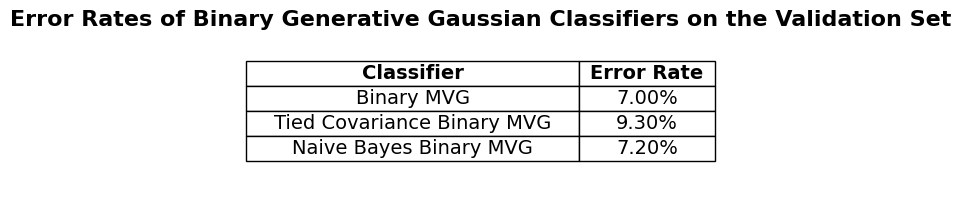

In [51]:
error_rates = [
    ("Binary MVG", error_rate_bin_MVG), 
    ("Tied Covariance Binary MVG", error_rate_bin_TiedCov),
    ("Naive Bayes Binary MVG", error_rate_bin_NB)
]

fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('tight')
ax.axis('off')

table_data = [[name, f"{error:.2%}"] for name, error in error_rates]
table = ax.table(cellText=table_data, colLabels=["Classifier", "Error Rate"], loc="center")

#center text in the cells
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')
    else:
        cell.set_text_props(ha='center', va='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.auto_set_column_width([0, 1])
table.scale(1.5, 1.5)  # Adjust the scale for better visibility
plt.title("Error Rates of Binary Generative Gaussian Classifiers on the Validation Set", fontsize=16, weight='bold')
plt.savefig("./models/ggm/error_rates_binary.png", bbox_inches='tight', dpi=300) #save the figure with a resolution of 300 dpi
plt.show()

### 4. Extensive Models Comparison
Let’s now analyze the results in light of the characteristics of the features of the dataset. <br>
I start by showing the Covariance Matrices $\Sigma_{c1}$, $\Sigma_{c2}$ for each one of the two classes, they are basically the MLE found for the MVG Classifier:

In [63]:
import seaborn as sns

def showBinaryProblemCovs(cov0, cov1, text="Covariance"):
    """
    Show the covariance matrices of the two classes in a binary classification problem.

    Parameters:
    - cov0 (ndarray): Covariance matrix for class 0.
    - cov1 (ndarray): Covariance matrix for class 1.
    """


    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    fig.suptitle(f"{text} Matrices of the Two Classes", fontsize=16, weight='bold')
    sns.heatmap(cov0, annot=True, cmap='coolwarm', fmt='.5f', cbar=True, square=True, linewidths=0.5, ax=axs[0])
    axs[0].set_title(f"{text} Matrix - Class False (0)")
    axs[0].set_xlabel("Features")
    axs[0].set_ylabel("Features")

    sns.heatmap(cov1, annot=True, cmap='coolwarm', fmt='.5f', cbar=True, square=True, linewidths=0.5, ax=axs[1])
    axs[1].set_title(f"{text} Matrix - Class True (1)")
    axs[1].set_xlabel("Features")
    axs[1].set_ylabel("Features")


    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Adjust the top to make room for the suptitle

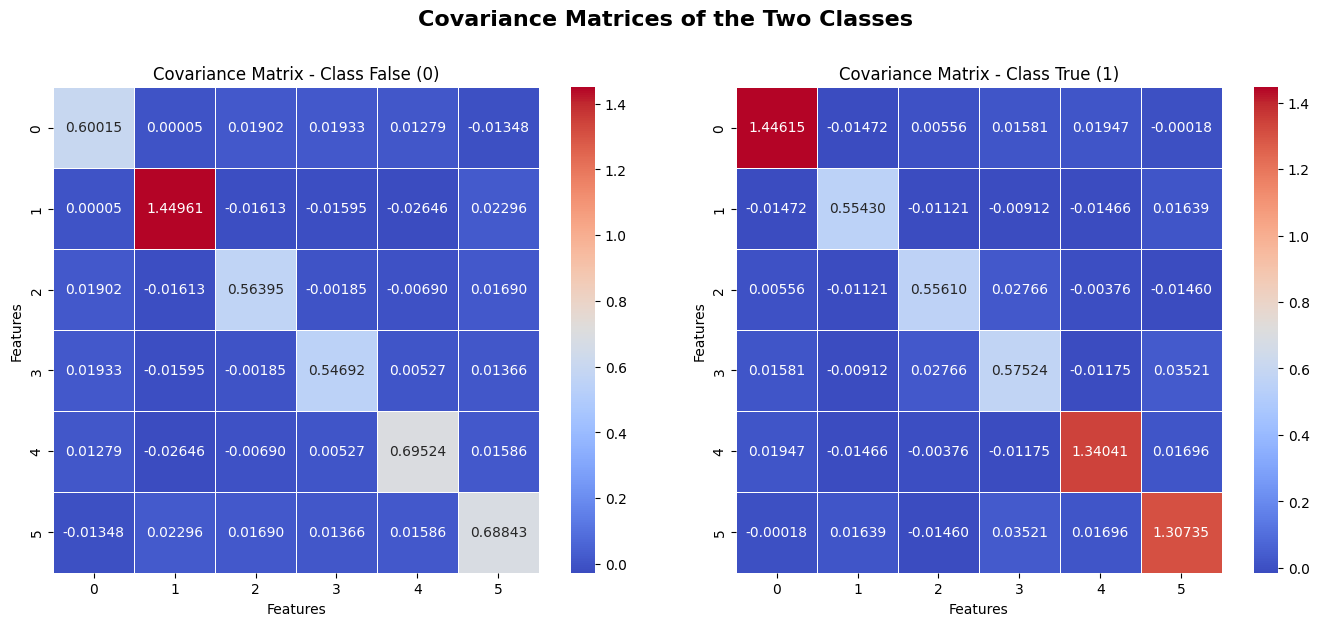

In [64]:
showBinaryProblemCovs(C_0, C_1)

The covariance matrices contain, on the diagonal, the variances for the different
features, whereas the elements outside of the diagonal are the co-variances of pairs of features. <br>
By comparing, for each class, the covariance of different feature pairs with the respective variances, we can understand the relative **strength of covariances with respect to variances**. The key points are:
- **Higher variances**: on the diagonal of both matrices we have higher elements, this means features variances are relatively higher and so, for each feature, samples have a bigger spread arount their respective means. For class False (0), feature $1$ shows the highest variance and feature $2$, $3$ show the lowest one. For class True (1), features $0$, $4$, $5$ show the highest variances and features $1$, $2$ show the lowest ones.
- **Lower, almost zero, covariances**: covariances computed for pairs of features are almost zero, for every class. This means the dataset doesn't show a significative linear relation between the different features.


I can compute the Pearson's Correlation Matrix to further visualize the strenght of variances against covariances:
$$
r_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}}
$$
where $i$, $j$ are two distinct features

In [ ]:
from correlation import computeCorrelation

#For each class compute the correlation matrix of the features having the Covariance matrix of the class

corr0 = computeCorrelation(C_0)
corr1 = computeCorrelation(C_1)
print(f"Correlation matrix for class 0 shape: {corr0.shape}")
print(f"Correlation matrix for class 1 shape: {corr1.shape}")


Correlation matrix for class 0 shape: (6, 6)
Correlation matrix for class 1 shape: (6, 6)


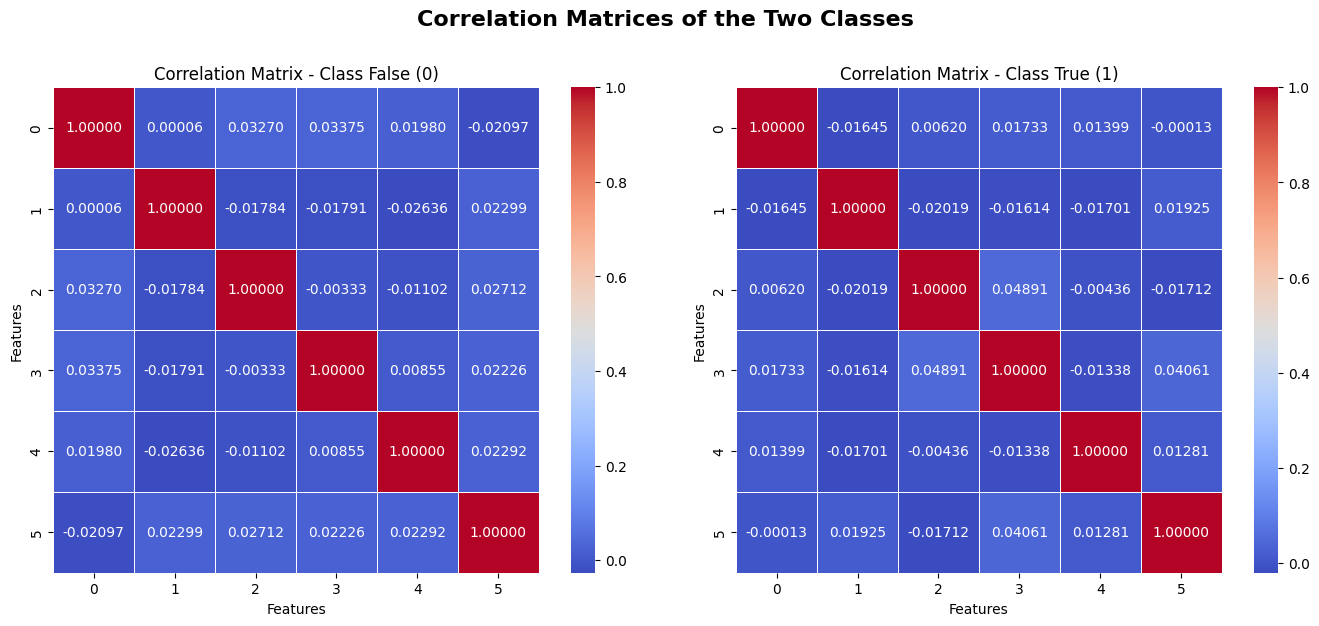

In [65]:
showBinaryProblemCovs(corr0, corr1, text="Correlation")

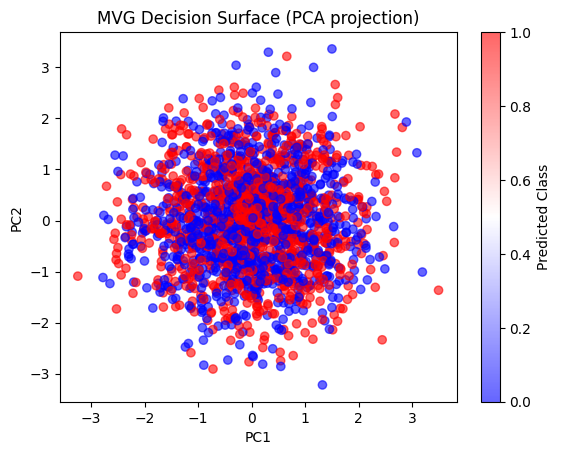

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assume X is your data matrix of shape (N, 6)
pca = PCA(n_components=6)
X_proj = pca.fit_transform(DVAL.reshape((DVAL.shape[1], DVAL.shape[0])))

# After projection, re-evaluate the log-likelihood ratio in the original space
llrs = llr_MVG
predictions = llrs >= 0

# Plot
plt.scatter(X_proj[:, 0], X_proj[:, 1], c=predictions, cmap='bwr', alpha=0.6)
plt.title('MVG Decision Surface (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Predicted Class')
plt.show()
